In [3]:
"""
Introducción al análisis basado en regiones

Objetivo
Presentar el análisis basado en regiones como un método clásico de visión artificial para identificar y medir regiones coherentes en imágenes.

Importancia
Hasta ahora, hemos estudiado métodos basados en bordes y descriptores de textura. Sin embargo, muchas tareas de procesamiento de imágenes científicas requieren identificar regiones conectadas y cuantificar sus propiedades.

El análisis basado en regiones constituye un puente natural entre el análisis de texturas y la segmentación.

Relevancia en el procesamiento de imágenes científicas
Los métodos basados en regiones son útiles en:
- Análisis de porosidad
- Detección de partículas
- Caracterización de defectos
- Análisis de fases de materiales
- Conjuntos de datos de tomografía y micro-CT
"""

'\nIntroducción al análisis basado en regiones\n\nObjetivo\nPresentar el análisis basado en regiones como un método clásico de visión artificial para identificar y medir regiones coherentes en imágenes.\n\nImportancia\nHasta ahora, hemos estudiado métodos basados en bordes y descriptores de textura. Sin embargo, muchas tareas de procesamiento de imágenes científicas requieren identificar regiones conectadas y cuantificar sus propiedades.\n\nEl análisis basado en regiones constituye un puente natural entre el análisis de texturas y la segmentación.\n\nRelevancia en el procesamiento de imágenes científicas\nLos métodos basados en regiones son útiles en:\n- Análisis de porosidad\n- Detección de partículas\n- Caracterización de defectos\n- Análisis de fases de materiales\n- Conjuntos de datos de tomografía y micro-CT\n'

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.ndimage import uniform_filter
from skimage import measure, morphology
from skimage.filters import threshold_otsu
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [5]:
np.random.seed(42)
def show_images(images, titles, cmap='gray', figsize=(14, 8), save_path=None):
    n = len(images)
    cols = min(3, n)
    rows = int(np.ceil(n / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)
    
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis('off')
    
    for ax in axes[len(images):]:
        ax.axis('off')
    
    plt.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


def local_variance(image, size=7):
    image = image.astype(np.float32)
    mean = uniform_filter(image, size=size)
    mean_sq = uniform_filter(image**2, size=size)
    return mean_sq - mean**2


def generate_synthetic_region_image(size=256, n_disks=12):
    image = np.zeros((size, size), dtype=np.float32)
    
    yy, xx = np.indices(image.shape)
    
    for _ in range(n_disks):
        r = np.random.randint(10, 25)
        cy = np.random.randint(r, size - r)
        cx = np.random.randint(r, size - r)
        
        mask = (xx - cx)**2 + (yy - cy)**2 <= r**2
        intensity = np.random.uniform(0.6, 1.0)
        image[mask] = intensity
    
    image += 0.15 * np.random.rand(size, size)
    image = np.clip(image, 0, 1)
    
    return image


def overlay_regions(image, labeled_image):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(image, cmap='gray')
    ax.imshow(labeled_image, cmap='nipy_spectral', alpha=0.45)
    ax.set_title("Region Overlay")
    ax.axis('off')
    plt.tight_layout()
    return fig


def regionprops_table_df(labeled_image, intensity_image=None):
    props = measure.regionprops_table(
        labeled_image,
        intensity_image=intensity_image,
        properties=[
            'label',
            'area',
            'perimeter',
            'eccentricity',
            'solidity',
            'bbox',
            'centroid',
            'mean_intensity'
        ]
    )
    return pd.DataFrame(props)

In [6]:
"""
Ejemplo sintético inspirado en una imagen científica

Para introducir el análisis basado en regiones, primero creamos una imagen sintética que contiene objetos brillantes incrustados en un fondo más oscuro.
Esta configuración simplificada simula situaciones en las que una imagen científica contiene:
- poros
- partículas
- inclusiones
- defectos
- fases brillantes o densas
"""

'\nEjemplo sintético inspirado en una imagen científica\n\nPara introducir el análisis basado en regiones, primero creamos una imagen sintética que contiene objetos brillantes incrustados en un fondo más oscuro.\nEsta configuración simplificada simula situaciones en las que una imagen científica contiene:\n- poros\n- partículas\n- inclusiones\n- defectos\n- fases brillantes o densas\n'

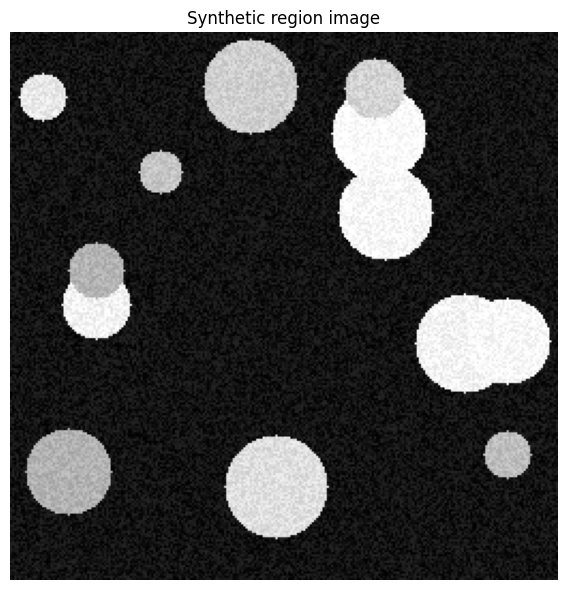

In [9]:
synthetic_image = generate_synthetic_region_image(size=256, n_disks=14)

show_images(
    [synthetic_image],
    ["Synthetic region image"],
    figsize=(6, 6),
    save_path="../figures/figures_region_based/synthetic_region_image.png"
)

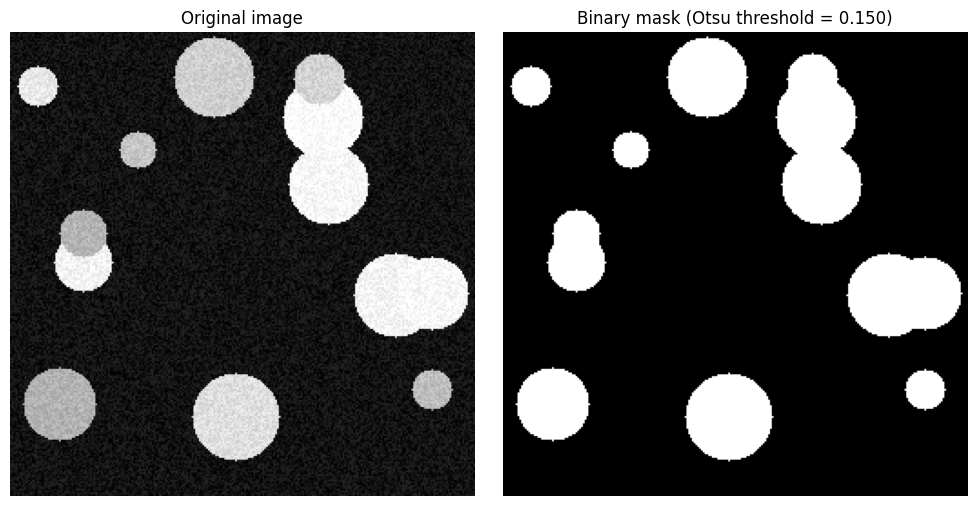

In [10]:
threshold_value = threshold_otsu(synthetic_image)
binary_mask = synthetic_image > threshold_value

show_images(
    [synthetic_image, binary_mask],
    [f"Original image", f"Binary mask (Otsu threshold = {threshold_value:.3f})"],
    figsize=(10, 5),
    save_path="../figures/figures_region_based/otsu_binary_mask.png"
)

In [11]:
"""
Limpieza morfológica

Las máscaras binarias reales suelen contener:
- pequeñas partículas de ruido
- diminutos agujeros
- fragmentos desconectados
Las operaciones morfológicas ayudan a limpiar la máscara antes del análisis de regiones.
"""

'\nLimpieza morfológica\n\nLas máscaras binarias reales suelen contener:\n- pequeñas partículas de ruido\n- diminutos agujeros\n- fragmentos desconectados\nLas operaciones morfológicas ayudan a limpiar la máscara antes del análisis de regiones.\n'

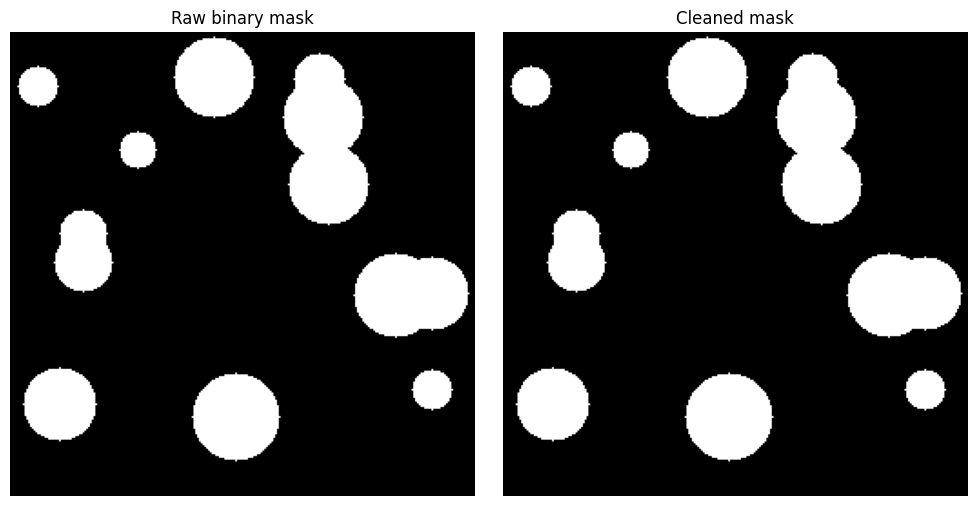

In [13]:
clean_mask = morphology.remove_small_objects(binary_mask, max_size=79)
clean_mask = morphology.remove_small_holes(clean_mask, max_size=79)

show_images(
    [binary_mask, clean_mask],
    ["Raw binary mask", "Cleaned mask"],
    figsize=(10, 5),
    #save_path="../figures/figures_region_based/mask_cleanup.png"
)

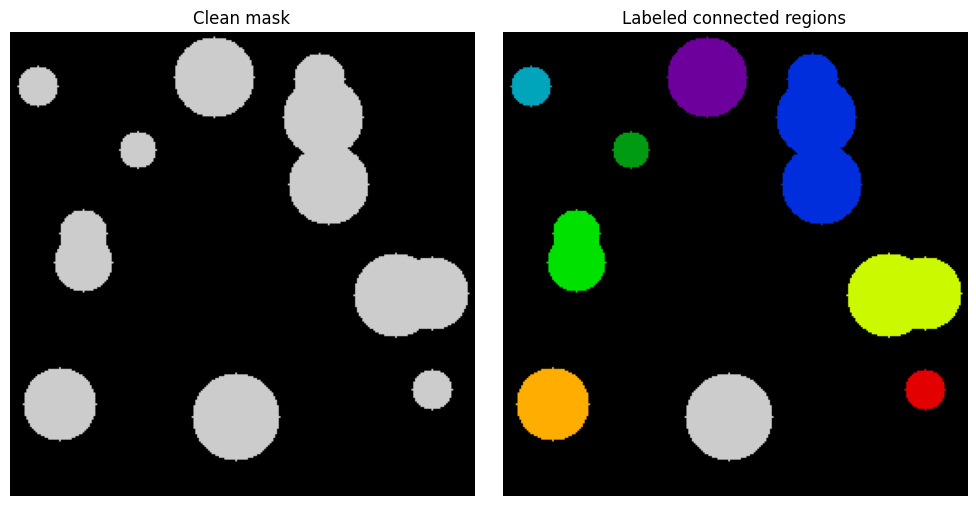

In [15]:
labeled_regions = measure.label(clean_mask)

show_images(
    [clean_mask, labeled_regions],
    ["Clean mask", "Labeled connected regions"],
    cmap='nipy_spectral',
    figsize=(10, 5),
    save_path="../figures/figures_region_based/labeled_regions.png"
)

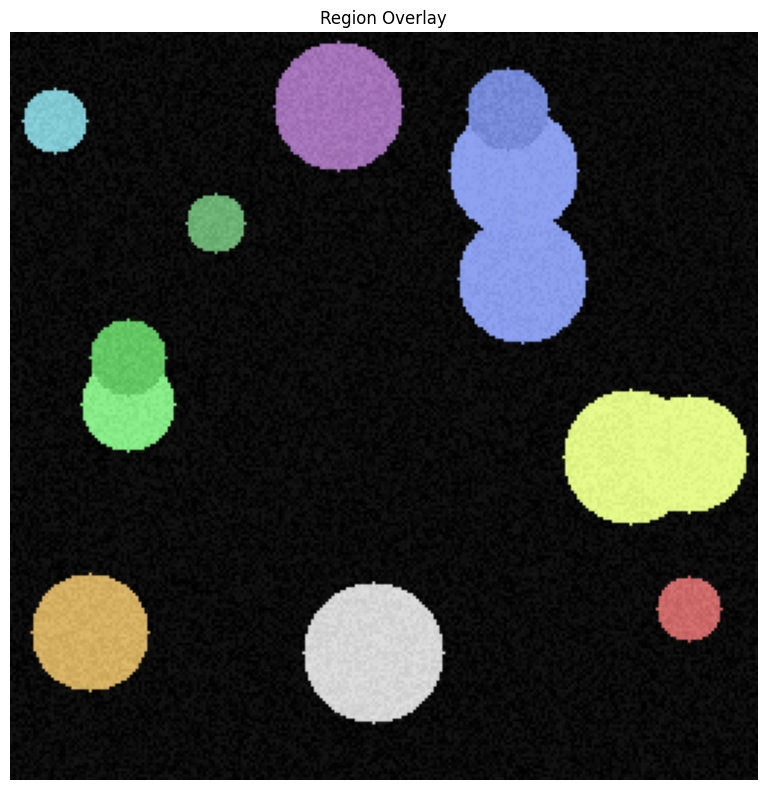

In [16]:
fig = overlay_regions(synthetic_image, labeled_regions)
os.makedirs("../figures/figures_region_based", exist_ok=True)
fig.savefig("../figures/figures_region_based/region_overlay.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
"""
Medición de las propiedades de una región
El análisis basado en regiones no solo consiste en detectar componentes conectados, sino también en cuantificarlos.
Algunas propiedades comunes de una región incluyen:
- Área
- Perímetro
- Excentricidad
- Solidez
- Centroide
- Caja delimitadora
- Intensidad media
"""

'\nMedición de las propiedades de una región\nEl análisis basado en regiones no solo consiste en detectar componentes conectados, sino también en cuantificarlos.\nAlgunas propiedades comunes de una región incluyen:\n- Área\n- Perímetro\n- Excentricidad\n- Solidez\n- Centroide\n- Caja delimitadora\n- Intensidad media\n'

In [18]:
df_regions = regionprops_table_df(labeled_regions, intensity_image=synthetic_image)
df_regions.head()

,label,area,perimeter,eccentricity,solidity,bbox-0,bbox-1,bbox-2,bbox-3,centroid-0,centroid-1,mean_intensity
0,1,1517.0,145.539105,0.000000,0.964399,3,90,48,135,25.000000,112.000000,0.810380
1,2,3250.0,262.835570,0.900298,0.902277,12,150,107,198,61.013538,173.097846,0.945274
2,3,377.0,71.597980,0.000000,0.940150,19,4,42,27,30.000000,15.000000,0.912010
3,4,317.0,65.941125,0.000000,0.929619,55,60,76,81,65.000000,70.000000,0.771396
4,5,1110.0,131.053824,0.745989,0.947099,98,24,144,57,121.245946,40.000000,0.832675


In [19]:
"""
Interpretación de las propiedades de la región

Estas mediciones tienen un significado físico.
Por ejemplo:
- El área puede representar el tamaño de las partículas o los poros.
- La excentricidad puede indicar el alargamiento.
- La solidez puede reflejar la compacidad.
- La intensidad media puede estar relacionada con el contraste de fase o la densidad.
"""

'\nInterpretación de las propiedades de la región\n\nEstas mediciones tienen un significado físico.\nPor ejemplo:\n- El área puede representar el tamaño de las partículas o los poros.\n- La excentricidad puede indicar el alargamiento.\n- La solidez puede reflejar la compacidad.\n- La intensidad media puede estar relacionada con el contraste de fase o la densidad.\n'

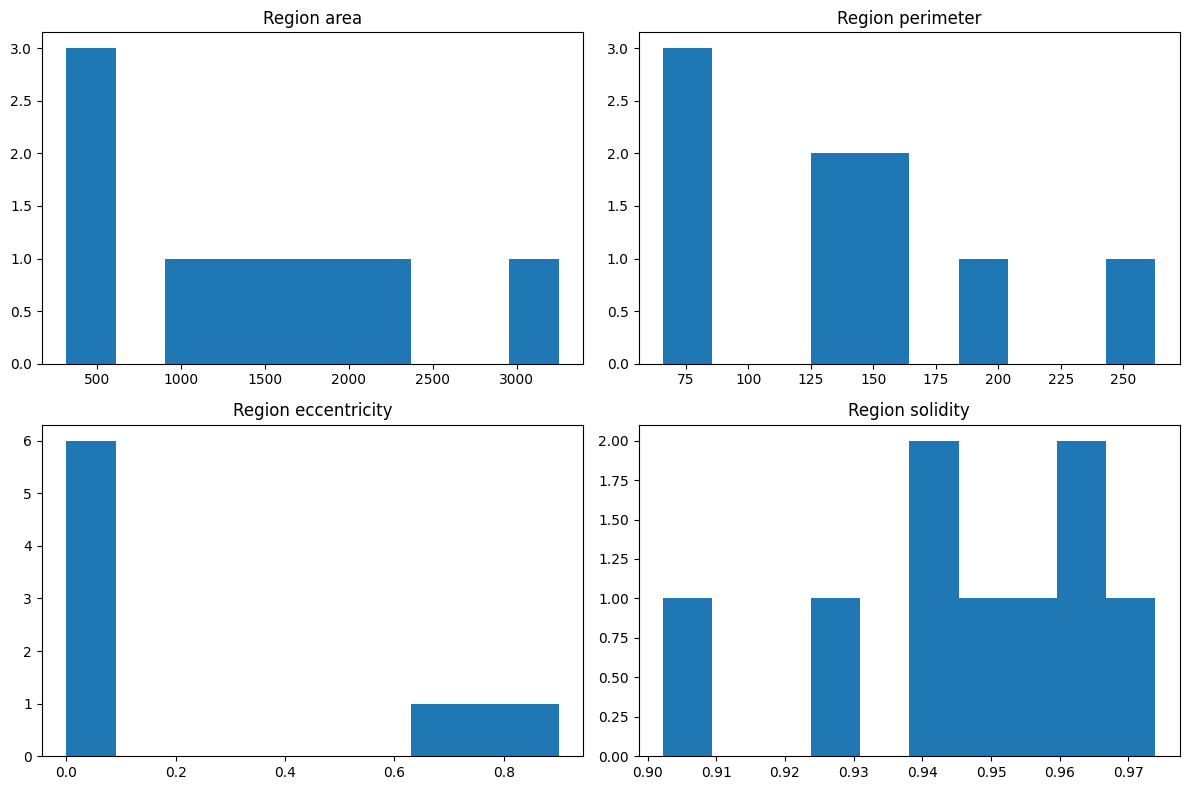

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(df_regions["area"], bins=10)
axes[0, 0].set_title("Region area")

axes[0, 1].hist(df_regions["perimeter"], bins=10)
axes[0, 1].set_title("Region perimeter")

axes[1, 0].hist(df_regions["eccentricity"], bins=10)
axes[1, 0].set_title("Region eccentricity")

axes[1, 1].hist(df_regions["solidity"], bins=10)
axes[1, 1].set_title("Region solidity")

plt.tight_layout()
plt.savefig("../figures/figures_region_based/region_properties_histograms.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
"""
Filtrado de regiones por tamaño

En el análisis práctico de imágenes, algunas regiones detectadas pueden ser irrelevantes:
- demasiado pequeñas
- demasiado grandes
- probablemente ruido
- sin significado físico
Podemos filtrar las regiones etiquetadas según sus propiedades.
"""

'\nFiltrado de regiones por tamaño\n\nEn el análisis práctico de imágenes, algunas regiones detectadas pueden ser irrelevantes:\n- demasiado pequeñas\n- demasiado grandes\n- probablemente ruido\n- sin significado físico\nPodemos filtrar las regiones etiquetadas según sus propiedades.\n'

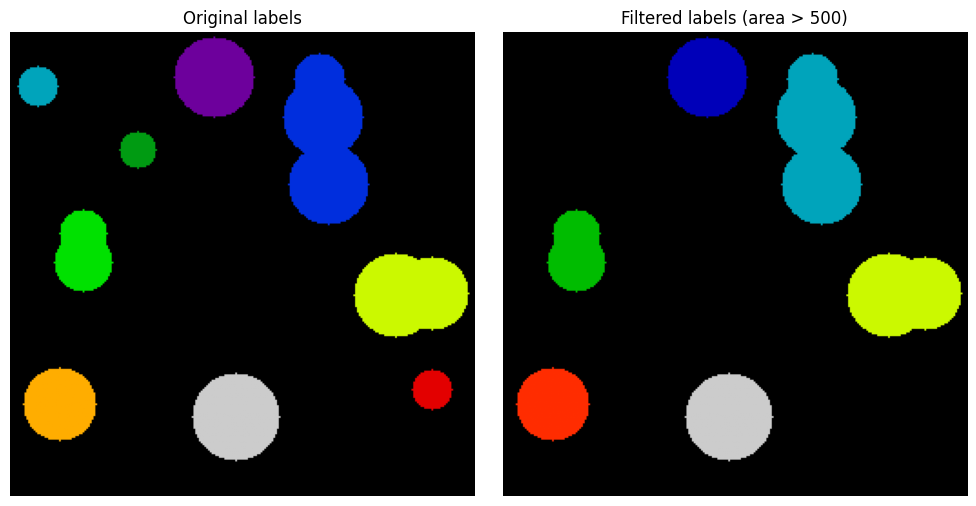

In [26]:
valid_labels = df_regions[df_regions["area"] > 500]["label"].values
filtered_mask = np.isin(labeled_regions, valid_labels)
filtered_labels = measure.label(filtered_mask)

show_images(
    [labeled_regions, filtered_labels],
    ["Original labels", "Filtered labels (area > 500)"],
    cmap='nipy_spectral',
    figsize=(10, 5),
    save_path="../figures/figures_region_based/filtered_regions.png"
)

In [35]:
def generate_labeled_region_dataset(n_images=20, size=256):
    feature_rows = []
    
    for _ in range(n_images):
        image = generate_synthetic_region_image(size=size, n_disks=np.random.randint(8, 16))
        threshold_value = threshold_otsu(image)
        mask = image > threshold_value

        # Updated for newer skimage versions:
        # old behavior: remove objects/holes with size < 80
        # new API uses max_size and removes size <= value
        mask = morphology.remove_small_objects(mask, max_size=79)
        mask = morphology.remove_small_holes(mask, max_size=79)

        labels = measure.label(mask)
        props = measure.regionprops(labels, intensity_image=image)
        
        for region in props:
            row = {
                "area": region.area,
                "perimeter": region.perimeter,
                "eccentricity": region.eccentricity,
                "solidity": region.solidity,
                "mean_intensity": region.intensity_mean,
            }
            
            # Toy label: large vs small regions
            row["class"] = 1 if region.area > 600 else 0
            feature_rows.append(row)
    
    return pd.DataFrame(feature_rows)

In [37]:
df_dataset = generate_labeled_region_dataset(n_images=25, size=256)
df_dataset.head()

,area,perimeter,eccentricity,solidity,mean_intensity,class
0,709.0,98.911688,0.000000,0.956815,0.809338,1
1,901.0,112.568542,0.000000,0.957492,0.848080,1
2,377.0,71.597980,0.000000,0.940150,0.928872,0
3,3451.0,250.936075,0.742009,0.920267,0.933557,1
4,1653.0,151.195959,0.000000,0.971781,0.777061,1


In [38]:
feature_cols = ["area", "perimeter", "eccentricity", "solidity", "mean_intensity"]

X = df_dataset[feature_cols].values
y = df_dataset["class"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [39]:
print(classification_report(y_test, y_pred, target_names=["Small region", "Large region"]))

              precision    recall  f1-score   support

Small region       1.00      1.00      1.00         8
Large region       1.00      1.00      1.00        38

    accuracy                           1.00        46
   macro avg       1.00      1.00      1.00        46
weighted avg       1.00      1.00      1.00        46



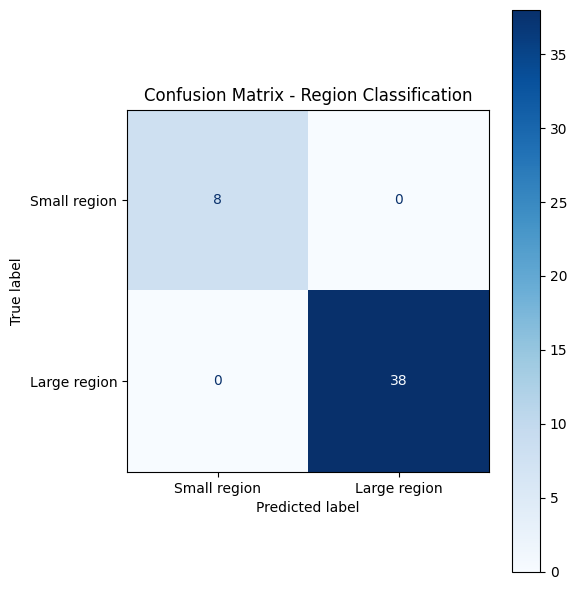

In [40]:
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Small region", "Large region"],
    cmap='Blues',
    ax=ax
)
plt.title("Confusion Matrix - Region Classification")
plt.tight_layout()
plt.savefig("../figures/figures_region_based/region_classification_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [41]:
"""
Interpretación de imágenes
El análisis basado en regiones es de gran relevancia en la obtención de imágenes, ya que muchas tareas se centran en objetos.
Algunos ejemplos son:
- Conteo de poros
- Medición del tamaño de partículas
- Identificación de inclusiones
- Cuantificación de defectos
- Separación de fases para su posterior análisis
Limitaciones de este enfoque introductorio
Este notebook utiliza un flujo de trabajo simplificado para el análisis de regiones de imágenes sinteticas.
Limitaciones importantes:
- El umbral binario puede fallar en imágenes de bajo contraste.
- Los objetos que se tocan pueden fusionarse en una sola región.
- Las propiedades de la región dependen en gran medida de la calidad de la segmentación.
- Las imágenes científicas reales son más ruidosas y complejas.
Estas limitaciones impulsan el desarrollo de métodos de segmentación más avanzados.
El análisis basado en regiones desplaza el enfoque de los descriptores de imagen locales a las estructuras conectadas que pueden medirse e interpretarse físicamente.
Esto lo convierte en un puente fundamental entre la visión artificial clásica y la segmentación de imágenes, especialmente en aplicaciones como la microtomografía computarizada (microCT), la caracterización de materiales y la tomografía.
"""

'\nInterpretación de imágenes\nEl análisis basado en regiones es de gran relevancia en la obtención de imágenes, ya que muchas tareas se centran en objetos.\nAlgunos ejemplos son:\n- Conteo de poros\n- Medición del tamaño de partículas\n- Identificación de inclusiones\n- Cuantificación de defectos\n- Separación de fases para su posterior análisis\nLimitaciones de este enfoque introductorio\nEste notebook utiliza un flujo de trabajo simplificado para el análisis de regiones de imágenes sinteticas.\nLimitaciones importantes:\n- El umbral binario puede fallar en imágenes de bajo contraste.\n- Los objetos que se tocan pueden fusionarse en una sola región.\n- Las propiedades de la región dependen en gran medida de la calidad de la segmentación.\n- Las imágenes científicas reales son más ruidosas y complejas.\nEstas limitaciones impulsan el desarrollo de métodos de segmentación más avanzados.\nEl análisis basado en regiones desplaza el enfoque de los descriptores de imagen locales a las estr